In [1]:
import pandas as pd
import numpy as np
import os
from pathlib import Path
from scipy.stats import spearmanr, rankdata
from joblib import Parallel, delayed
import warnings
import gc
import argparse
from tqdm.auto import tqdm
import glob
import matplotlib.pyplot as plt
import networkx as nx
import re
import sys
import json

In [2]:
#Path to TwINFER code repository
path_to_code_repo = "/home/gzu5140/Keerthana_b1042/TwINFER/code/TwINFER/"
path_to_simulation_data = "/home/gzu5140/Keerthana_b1042/TwINFER/simulation_data/network_sweep_final/"
path_to_twinfer_output = "/home/gzu5140/Keerthana_b1042/TwINFER/analysis_data/network_sweep_final/network_inference/"

In [3]:
def find_confounded_pairs(ground_truth_matrix, gene_names):
    """
    Identifies gene pairs with no direct edge between them but sharing at
    least one common regulator (fan-out / feed-forward fork: gk->gi and
    gk->gj). Such pairs are expected to show correlation from shared
    upstream regulation even though they are not truly regulatory edges, so
    they should be scored as an expected multi-state case rather than a
    straightforward false positive/negative.

    Pairs with a real direct edge between them -- including true mutual
    (bidirectional) regulation -- are excluded, since genuine regulation
    should be scored normally, not treated as a confound.

    Args:
        ground_truth_matrix (pd.DataFrame): Square matrix labeled with gene names.
        gene_names (list of str): Gene names for this network.

    Returns:
        set of frozenset: Unordered gene pairs identified as confounded (fan-out) pairs.
    """
    confounded_pairs = set()
    n = len(gene_names)
    for idx_i in range(n):
        for idx_j in range(idx_i + 1, n):
            gi, gj = gene_names[idx_i], gene_names[idx_j]
            if ground_truth_matrix.loc[gi, gj] != 0 and ground_truth_matrix.loc[gj, gi] != 0:
                continue  # real direct edge (incl. mutual) -- not a confound case
            shared_regulator = any(
                ground_truth_matrix.loc[gk, gi] != 0 and ground_truth_matrix.loc[gk, gj] != 0
                for gk in gene_names if gk not in (gi, gj)
            )
            if shared_regulator:
                confounded_pairs.add(frozenset([gi, gj]))
    return confounded_pairs


def score_directed_edges(ground_truth_matrix, gene_names, final_directed_edges,
                         multiple_states, direction_matrix,
                         wrong_sign_counts_as=("FP", "FN")):
    """
    Computes precision, recall, and F1 for directed edge inference against a
    ground-truth connectivity matrix, at two strictness levels computed side
    by side from the same pass over gene pairs, with confounded (fan-out)
    pairs scored specially:

    - Sign-blind (TP/FP/FN/precision/recall/f1): an edge counts as present
      in the ground truth if nonzero (either sign), and a predicted edge is
      a TP as soon as the pair appears in final_directed_edges -- the
      predicted sign is never consulted. This mirrors the same sign-blind
      convention evaluate_networksweep_beeline.ipynb uses for the BEELINE
      algorithms' plain precision_topk/recall_topk/f1_topk columns, so the
      two are directly comparable.
    - Directed AND signed (TP_signed/FP_signed/FN_signed/precision_signed/
      recall_signed/f1_signed -- the strictest level): a predicted edge is
      only a full match (TP_signed) if BOTH the pair appears in
      final_directed_edges AND direction_matrix's sign at [gi, gj] agrees
      with the ground-truth sign. A predicted edge with the wrong sign is
      tracked as WRONG_SIGN and, by default, counted as both an FP_signed
      (an incorrect signed claim was made) and an FN_signed (the true
      signed edge was not recovered) -- change wrong_sign_counts_as to
      alter this convention. This mirrors evaluate_networksweep_beeline
      .ipynb's precision_topk_signed/etc. columns.

    TN doesn't depend on sign at all (a true negative is "no prediction,
    no ground-truth edge" regardless of any sign), so there's a single
    shared TN count rather than a TN/TN_signed pair.

    Confounded pairs (see find_confounded_pairs) are scored as follows,
    for each unordered pair {gi, gj} (evaluated once):
      - If flagged as multi-state (either [gi, gj] or [gj, gi] appears in
        multiple_states): TN += 2, and the pair counts toward
        confounded_pairs_correctly_found. No other scoring is applied
        (identical for both strictness levels).
      - Otherwise, if neither direction has a real edge in the ground truth:
          - both directions predicted -> FP += 2 (neither prediction
            matches the ground truth).
          - one direction predicted -> that direction is FP, the other TN.
          - neither predicted -> TN += 2.
        (Identical for both strictness levels -- no real edge exists in
        either direction, so there's no sign to match.)
      - Otherwise (exactly one direction has a real edge, call it a->b):
          - the a->b prediction is scored normally for each level (TP if
            predicted -- with matching sign, for the signed level; FN if
            not predicted).
          - the reverse (b->a) prediction is scored as FP if predicted,
            TN if not predicted (same for both levels).
        So a fully correct call yields one TP and one TN.

    Args:
        ground_truth_matrix (pd.DataFrame): Square matrix labeled with gene names.
        gene_names (list of str): Gene names for this network.
        final_directed_edges (list of [str, str] or tuple): Predicted directed edges.
        multiple_states (list of [str, str]): Pairs flagged as multi-state regulation.
        direction_matrix (pd.DataFrame): Inferred directional correlation matrix
                                         (e.g. reconstructed unfiltered_direction_matrix);
                                         its sign at [gi, gj] is checked against
                                         ground truth for any predicted edge.
        wrong_sign_counts_as (tuple of str): Which signed counters a
                                             wrong-signed prediction increments.
                                             Any subset of ("FP", "FN").
                                             Default counts it as both.

    Returns:
        dict: TP, FP, FN, TN (sign-blind) and TP_signed, FP_signed,
             FN_signed, WRONG_SIGN (directed AND signed) counts; precision,
             recall, f1 (sign-blind) and precision_signed, recall_signed,
             f1_signed (directed AND signed); edge lists per category; and
             confounded_pairs.
    """
    predicted_edges = set(tuple(e) for e in final_directed_edges)
    confounded_pairs = find_confounded_pairs(ground_truth_matrix, gene_names)
    scored_confounded = set()

    TP = FP = FN = TN = 0
    TP_signed = FP_signed = FN_signed = WRONG_SIGN = 0
    TP_edges, FP_edges, FN_edges = [], [], []
    TP_signed_edges, FP_signed_edges, FN_signed_edges, WRONG_SIGN_edges = [], [], [], []
    confounded_correct = 0

    def _sign_match(a, b):
        gt_sign = int(np.sign(ground_truth_matrix.loc[a, b]))
        pred_sign_val = direction_matrix.loc[a, b]
        pred_sign = int(np.sign(pred_sign_val)) if pred_sign_val != 0 else 0
        return pred_sign == gt_sign

    for gi in gene_names:
        for gj in gene_names:
            if gi == gj:
                continue

            pair_fs = frozenset([gi, gj])

            if pair_fs in confounded_pairs:
                if pair_fs in scored_confounded:
                    continue
                scored_confounded.add(pair_fs)

                is_flagged_multistate = (
                    [gi, gj] in multiple_states or [gj, gi] in multiple_states
                )

                if is_flagged_multistate:
                    TN += 2
                    confounded_correct += 1
                    continue

                has_gi_gj = (gi, gj) in predicted_edges
                has_gj_gi = (gj, gi) in predicted_edges

                gt_gi_gj = ground_truth_matrix.loc[gi, gj] != 0
                gt_gj_gi = ground_truth_matrix.loc[gj, gi] != 0

                if not gt_gi_gj and not gt_gj_gi:
                    # No real edge in either direction -- identical for both
                    # strictness levels, since there's no sign to match.
                    if has_gi_gj and has_gj_gi:
                        # Both directions predicted but neither matches the
                        # ground truth (no real edge at all) -> 2 FPs.
                        FP += 2
                        FP_signed += 2
                        FP_edges.append((gi, gj))
                        FP_edges.append((gj, gi))
                        FP_signed_edges.append((gi, gj))
                        FP_signed_edges.append((gj, gi))
                    elif has_gi_gj or has_gj_gi:
                        FP += 1
                        FP_signed += 1
                        TN += 1
                        edge = (gi, gj) if has_gi_gj else (gj, gi)
                        FP_edges.append(edge)
                        FP_signed_edges.append(edge)
                    else:
                        TN += 2
                else:
                    # Exactly one direction has a real edge.
                    if gt_gi_gj:
                        real_a, real_b = gi, gj
                    else:
                        real_a, real_b = gj, gi

                    real_pred = (real_a, real_b) in predicted_edges
                    fake_pred = (real_b, real_a) in predicted_edges

                    # Sign-blind: TP as soon as the pair is predicted, sign unchecked.
                    if real_pred:
                        TP += 1
                        TP_edges.append((real_a, real_b))
                    else:
                        FN += 1
                        FN_edges.append((real_a, real_b))

                    # Directed AND signed: TP_signed only if sign also matches.
                    if real_pred and _sign_match(real_a, real_b):
                        TP_signed += 1
                        TP_signed_edges.append((real_a, real_b))
                    elif real_pred:
                        WRONG_SIGN += 1
                        WRONG_SIGN_edges.append((real_a, real_b))
                        if "FP" in wrong_sign_counts_as:
                            FP_signed += 1
                            FP_signed_edges.append((real_a, real_b))
                        if "FN" in wrong_sign_counts_as:
                            FN_signed += 1
                            FN_signed_edges.append((real_a, real_b))
                    else:
                        FN_signed += 1
                        FN_signed_edges.append((real_a, real_b))

                    if fake_pred:
                        FP += 1
                        FP_signed += 1
                        FP_edges.append((real_b, real_a))
                        FP_signed_edges.append((real_b, real_a))
                    else:
                        TN += 1

                continue

            # Non-confounded pairs: standard scoring.
            gt_sign_val = ground_truth_matrix.loc[gi, gj]
            gt_edge = gt_sign_val != 0
            gt_sign = int(np.sign(gt_sign_val))

            pred_edge = (gi, gj) in predicted_edges

            if gt_edge and pred_edge:
                # Sign-blind: TP regardless of predicted sign.
                TP += 1
                TP_edges.append((gi, gj))

                # Directed AND signed: TP_signed only if sign also matches.
                pred_sign_val = direction_matrix.loc[gi, gj]
                pred_sign = int(np.sign(pred_sign_val)) if pred_sign_val != 0 else 0
                sign_match = (pred_sign == gt_sign)

                if sign_match:
                    TP_signed += 1
                    TP_signed_edges.append((gi, gj))
                else:
                    WRONG_SIGN += 1
                    WRONG_SIGN_edges.append((gi, gj))
                    if "FP" in wrong_sign_counts_as:
                        FP_signed += 1
                        FP_signed_edges.append((gi, gj))
                    if "FN" in wrong_sign_counts_as:
                        FN_signed += 1
                        FN_signed_edges.append((gi, gj))

            elif gt_edge and not pred_edge:
                FN += 1
                FN_edges.append((gi, gj))
                FN_signed += 1
                FN_signed_edges.append((gi, gj))
            elif not gt_edge and pred_edge:
                FP += 1
                FP_edges.append((gi, gj))
                FP_signed += 1
                FP_signed_edges.append((gi, gj))
            else:
                TN += 1

    precision = TP / (TP + FP) if (TP + FP) else 0.0
    recall = TP / (TP + FN) if (TP + FN) else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0

    precision_signed = TP_signed / (TP_signed + FP_signed) if (TP_signed + FP_signed) else 0.0
    recall_signed = TP_signed / (TP_signed + FN_signed) if (TP_signed + FN_signed) else 0.0
    f1_signed = (
        2 * precision_signed * recall_signed / (precision_signed + recall_signed)
        if (precision_signed + recall_signed) else 0.0
    )

    return {
        "TP": TP, "FP": FP, "FN": FN, "TN": TN,
        "precision": precision, "recall": recall, "f1": f1,
        "TP_edges": TP_edges, "FP_edges": FP_edges, "FN_edges": FN_edges,
        "TP_signed": TP_signed, "FP_signed": FP_signed, "FN_signed": FN_signed,
        "WRONG_SIGN": WRONG_SIGN,
        "precision_signed": precision_signed, "recall_signed": recall_signed, "f1_signed": f1_signed,
        "TP_signed_edges": TP_signed_edges, "FP_signed_edges": FP_signed_edges,
        "FN_signed_edges": FN_signed_edges, "WRONG_SIGN_edges": WRONG_SIGN_edges,
        "confounded_pairs": confounded_pairs,
        "confounded_pairs_correctly_found": confounded_correct,
    }
def load_ground_truth_matrix(path_to_matrix, gene_names=None):
    """
    Loads a connectivity matrix and labels it with gene names for lookup.

    Args:
        path_to_matrix (str): Path to the comma-separated connectivity matrix.
        gene_names (list of str, optional): Gene names matching matrix row/
                                            column order. If None, defaults
                                            to gene_1, gene_2, ....

    Returns:
        pd.DataFrame: Square matrix labeled with gene_names on both axes.
    """
    matrix = np.loadtxt(path_to_matrix, dtype=int, delimiter=',')
    n = matrix.shape[0]
    if gene_names is None:
        gene_names = [f"gene_{i+1}" for i in range(n)]
    return pd.DataFrame(matrix, index=gene_names, columns=gene_names)

In [4]:
def reconstruct_ranked_edge_list(raw):
    """
    Reconstructs infer_with_twinfer's ranked_edge_list (columns gene_1, gene_2,
    directional_correlation, p_val) from the {'__type__': 'DataFrame', 'index':
    ..., 'columns': ..., 'data': ...} wrapper format used in these result JSONs.

    Args:
        raw : dict or None
            results.get("ranked_edge_list") from a loaded result JSON. None if
            the key is absent (e.g. the JSON predates infer_with_twinfer's
            ranked_list=True option, or ranked_list wasn't requested for that run).

    Returns:
        pd.DataFrame or None: None if raw is None/not the expected wrapper format.
    """
    if isinstance(raw, dict) and raw.get("__type__") == "DataFrame":
        return pd.DataFrame(raw["data"], columns=raw["columns"])
    return None


def compute_twinfer_auprc(ranked_edge_list, ground_truth_matrix, gene_names):
    """
    AUPRC for TwINFER's ranked_edge_list against a ground-truth connectivity matrix.

    Scoring universe mirrors the sibling evaluate_networksweep_beeline.ipynb
    notebook's compute_auprc (every directed non-self-loop gene pair; ground
    truth = nonzero entries), for direct comparability with the BEELINE
    algorithms scored there.

    Score = |directional_correlation| + 1e-6*(1 - p_val): cross-correlation
    magnitude is the primary ranking criterion, p-value only breaks ties
    (lower p-value ranks higher within a magnitude tie). The 1e-6 factor is
    far below any real magnitude difference -- directional_correlation is a
    correlation in [-1, 1] with much finer resolution than that -- so it can
    only affect genuine magnitude ties, never override a real magnitude
    difference.

    Any (gi, gj) pair absent from ranked_edge_list -- not in the tested
    candidate set for this run's infer_direction_for_which_edges mode, or
    its unfiltered_direction_matrix entry was exactly zero -- gets score 0
    (the lowest possible), correctly placing it last rather than excluding
    it from the curve.

    Args:
        ranked_edge_list (pd.DataFrame or None): Output of
            reconstruct_ranked_edge_list. NaN is returned if None/empty.
        ground_truth_matrix (pd.DataFrame): Square matrix labeled with gene names.
        gene_names (list of str): Gene names for this network.

    Returns:
        float: AUPRC, or NaN if there's no ranked_edge_list or no true edges.
    """
    from itertools import permutations
    from sklearn.metrics import auc, precision_recall_curve

    possible_edges = list(permutations(gene_names, 2))
    true_labels = [1 if ground_truth_matrix.loc[gi, gj] != 0 else 0 for gi, gj in possible_edges]
    if sum(true_labels) == 0:
        return float("nan")

    if ranked_edge_list is None or ranked_edge_list.empty:
        return float("nan")

    score_lookup = {
        (row.gene_1, row.gene_2): abs(row.directional_correlation) + 1e-6 * (1 - row.p_val)
        for row in ranked_edge_list.itertuples()
    }
    pred_scores = [score_lookup.get(e, 0.0) for e in possible_edges]

    precision, recall, _ = precision_recall_curve(true_labels, pred_scores)
    return float(auc(recall, precision))


def compute_twinfer_auprc_signed(ranked_edge_list, ground_truth_matrix, gene_names):
    """
    AUPRC over directed AND signed edges for TwINFER's ranked_edge_list -- the
    TwINFER-side counterpart to evaluate_networksweep_beeline.ipynb's
    compute_auprc_signed. ground_truth_matrix is already signed (+1/-1/0, see
    load_ground_truth_matrix), and directional_correlation's sign is
    ranked_edge_list's predicted sign, so this is directly reconstructable
    -- unlike auprc_signed/auprc_undirected in the summary-level
    twinfer_analysis_output.csv columns TP/FP/FN/precision/recall/f1, which
    are already collapsed to sign-blind counts.

    Scoring universe is every directed pair x both signs. A prediction only
    scores at the sign position it actually predicted (sign of
    directional_correlation), so a wrong-signed prediction is an explicit
    false positive at that sign-position (full score credited there) while
    the true signed position gets zero credit -- mirroring
    compute_auprc_signed's convention exactly.

    Args:
        ranked_edge_list (pd.DataFrame or None): Output of
            reconstruct_ranked_edge_list. NaN is returned if None/empty.
        ground_truth_matrix (pd.DataFrame): Square SIGNED matrix (+1/-1/0)
            labeled with gene names.
        gene_names (list of str): Gene names for this network.

    Returns:
        float: AUPRC, or NaN if there's no ranked_edge_list or no true signed edges.
    """
    from itertools import permutations
    from sklearn.metrics import auc, precision_recall_curve

    possible_edges = list(permutations(gene_names, 2))
    possible_signed_positions = [(gi, gj, s) for gi, gj in possible_edges for s in (1, -1)]
    true_labels = [
        1 if int(np.sign(ground_truth_matrix.loc[gi, gj])) == s else 0
        for gi, gj, s in possible_signed_positions
    ]
    if sum(true_labels) == 0:
        return float("nan")

    if ranked_edge_list is None or ranked_edge_list.empty:
        return float("nan")

    score_lookup = {
        (row.gene_1, row.gene_2): (
            abs(row.directional_correlation) + 1e-6 * (1 - row.p_val),
            int(np.sign(row.directional_correlation)),
        )
        for row in ranked_edge_list.itertuples()
    }

    pred_scores = []
    for gi, gj, s in possible_signed_positions:
        entry = score_lookup.get((gi, gj))
        pred_scores.append(entry[0] if entry is not None and entry[1] == s else 0.0)

    precision, recall, _ = precision_recall_curve(true_labels, pred_scores)
    return float(auc(recall, precision))


def compute_twinfer_auprc_undirected(ranked_edge_list, ground_truth_matrix, gene_names):
    """
    AUPRC over undirected, unsigned edges for TwINFER's ranked_edge_list --
    the TwINFER-side counterpart to evaluate_networksweep_beeline.ipynb's
    compute_auprc_undirected. Only "is there any relationship between these
    two genes" is scored: (gi, gj) and (gj, gi) collapse into one
    frozenset({gi, gj}) position, true if EITHER direction is nonzero in
    ground_truth_matrix, and credited with whichever of the two predicted
    directions scored higher in ranked_edge_list.

    Args:
        ranked_edge_list (pd.DataFrame or None): Output of
            reconstruct_ranked_edge_list. NaN is returned if None/empty.
        ground_truth_matrix (pd.DataFrame): Square matrix labeled with gene names.
        gene_names (list of str): Gene names for this network.

    Returns:
        float: AUPRC, or NaN if there's no ranked_edge_list or no true undirected edges.
    """
    from itertools import combinations
    from sklearn.metrics import auc, precision_recall_curve

    unordered_pairs = list(combinations(gene_names, 2))
    possible_pairs = [frozenset(p) for p in unordered_pairs]
    true_labels = [
        1 if (ground_truth_matrix.loc[gi, gj] != 0 or ground_truth_matrix.loc[gj, gi] != 0) else 0
        for gi, gj in unordered_pairs
    ]
    if sum(true_labels) == 0:
        return float("nan")

    if ranked_edge_list is None or ranked_edge_list.empty:
        return float("nan")

    score_lookup = {}
    for row in ranked_edge_list.itertuples():
        score = abs(row.directional_correlation) + 1e-6 * (1 - row.p_val)
        pair = frozenset((row.gene_1, row.gene_2))
        if pair not in score_lookup or score > score_lookup[pair]:
            score_lookup[pair] = score

    pred_scores = [score_lookup.get(p, 0.0) for p in possible_pairs]

    precision, recall, _ = precision_recall_curve(true_labels, pred_scores)
    return float(auc(recall, precision))

In [5]:
def build_directed_true_edges(ground_truth_matrix, gene_names):
    """
    Set of directed (gi, gj) pairs with a nonzero (sign-blind) ground-truth
    edge -- the true-edge side of the same directed, non-self-loop edge
    universe evaluate_networksweep_final_beeline.ipynb's build_edge_universe
    uses for the BEELINE algorithms, so TwINFER's top-k metrics below are
    directly comparable to their precision_topk/recall_topk/f1_topk columns.

    Args:
        ground_truth_matrix (pd.DataFrame): Square matrix labeled with gene names.
        gene_names (list of str): Gene names for this network.

    Returns:
        set of tuple: True directed (gi, gj) edges.
    """
    return {
        (gi, gj)
        for gi in gene_names for gj in gene_names
        if gi != gj and ground_truth_matrix.loc[gi, gj] != 0
    }


def top_k_tie_aware_selection_twinfer(ranked_edge_list, num_true_edges):
    """
    Selects TwINFER's top-k predicted directed edges (k = num_true_edges)
    from its ranked_edge_list, expanded to include all ties at the boundary
    score -- the same tie-aware boundary logic as
    evaluate_networksweep_final_beeline.ipynb's top_k_tie_aware_selection,
    applied here to TwINFER's own ranking score (|directional_correlation|
    + 1e-6*(1 - p_val), the same score compute_twinfer_auprc ranks by)
    instead of an external algorithm's EdgeWeight column.

    Args:
        ranked_edge_list (pd.DataFrame or None): Output of
            reconstruct_ranked_edge_list. None if this result JSON predates
            infer_with_twinfer's ranked_list=True option.
        num_true_edges (int): k, the ground-truth directed edge count to
                              threshold at.

    Returns:
        tuple: (selected_edge_set of (gene_1, gene_2) tuples,
               threshold_score_used). (set(), NaN) if there's no
               ranked_edge_list or no true edges to threshold against.
    """
    if ranked_edge_list is None or ranked_edge_list.empty or num_true_edges == 0:
        return set(), float("nan")

    scored = ranked_edge_list.copy()
    scored["_score"] = scored["directional_correlation"].abs() + 1e-6 * (1 - scored["p_val"])
    scored = scored.sort_values("_score", ascending=False).reset_index(drop=True)

    maxk = min(len(scored), num_true_edges)
    edge_score_topk = float(scored.iloc[maxk - 1]["_score"])

    nonzero = scored.loc[scored["_score"] > 0, "_score"]
    non_zero_min = float(nonzero.min()) if not nonzero.empty else 0.0

    best_val = max(non_zero_min, edge_score_topk)
    selected = scored[scored["_score"] >= best_val]
    return set(zip(selected["gene_1"], selected["gene_2"])), best_val


def precision_recall_f1(selected_edges, true_edges):
    """
    Precision/recall/F1 of a selected directed-edge set against the true
    directed-edge set -- same definition as
    evaluate_networksweep_final_beeline.ipynb's precision_recall_f1.

    Args:
        selected_edges (set of tuple): Predicted directed (gi, gj) edges.
        true_edges (set of tuple): Ground-truth directed (gi, gj) edges.

    Returns:
        tuple: (precision, recall, f1). All 0.0 if selected_edges is empty.
    """
    if not selected_edges:
        return 0.0, 0.0, 0.0
    tp = len(selected_edges & true_edges)
    precision = tp / len(selected_edges)
    recall = tp / len(true_edges) if true_edges else float("nan")
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
    return precision, recall, f1

def build_directed_true_edges_signed(ground_truth_matrix, gene_names):
    """
    Set of directed (gi, gj, sign) triples for every real ground-truth edge,
    sign as int(np.sign(...)) (+1/-1) -- the signed counterpart to
    build_directed_true_edges. Cardinality equals build_directed_true_edges's
    (each real edge has exactly one true sign), matching TP_signed + FN_signed
    from score_directed_edges (every real edge is either a full match --
    TP_signed -- or not -- FN_signed, whether missed entirely or predicted
    with the wrong sign).

    Args:
        ground_truth_matrix (pd.DataFrame): Square SIGNED matrix (+1/-1/0)
            labeled with gene names.
        gene_names (list of str): Gene names for this network.

    Returns:
        set of tuple: True directed (gi, gj, sign) edges.
    """
    true_edges = set()
    for gi in gene_names:
        for gj in gene_names:
            if gi == gj:
                continue
            val = ground_truth_matrix.loc[gi, gj]
            if val != 0:
                true_edges.add((gi, gj, int(np.sign(val))))
    return true_edges


def top_k_tie_aware_selection_twinfer_signed(ranked_edge_list, num_true_edges_signed):
    """
    Signed counterpart to top_k_tie_aware_selection_twinfer -- the TwINFER-side
    equivalent of evaluate_networksweep_final_beeline.ipynb's
    top_k_tie_aware_selection_signed. Selection is still by the same
    magnitude-only ranking score (sign doesn't affect which edges are in the
    top-k, only which sign gets attached to each one selected), but the
    returned edges are (gene_1, gene_2, predicted_sign) triples instead of
    (gene_1, gene_2) pairs. num_true_edges_signed should be the same k as
    the sign-blind case (see build_directed_true_edges_signed) -- only the
    *possible*-position universe used for AUPRC doubles for signed scoring,
    not k here.

    Args:
        ranked_edge_list (pd.DataFrame or None): Output of
            reconstruct_ranked_edge_list.
        num_true_edges_signed (int): k, the ground-truth signed edge count
                                     to threshold at.

    Returns:
        tuple: (selected_edge_set of (gene_1, gene_2, sign) triples,
               threshold_score_used).
    """
    if ranked_edge_list is None or ranked_edge_list.empty or num_true_edges_signed == 0:
        return set(), float("nan")

    scored = ranked_edge_list.copy()
    scored["_score"] = scored["directional_correlation"].abs() + 1e-6 * (1 - scored["p_val"])
    scored["_sign"] = np.sign(scored["directional_correlation"]).astype(int)
    scored = scored.sort_values("_score", ascending=False).reset_index(drop=True)

    maxk = min(len(scored), num_true_edges_signed)
    edge_score_topk = float(scored.iloc[maxk - 1]["_score"])

    nonzero = scored.loc[scored["_score"] > 0, "_score"]
    non_zero_min = float(nonzero.min()) if not nonzero.empty else 0.0

    best_val = max(non_zero_min, edge_score_topk)
    selected = scored[scored["_score"] >= best_val]
    return set(zip(selected["gene_1"], selected["gene_2"], selected["_sign"])), best_val


In [6]:
import os
import re
import glob
import json
import pandas as pd


def build_network_stem_lookup(network_dir, prefix="grn_n", suffix=".txt"):
    """
    Builds a lookup from topology stem (e.g. 'e5_pos50_density_rep0') to full
    ground-truth matrix file path, by stripping the known prefix (e.g.
    'grn_n6_') and suffix from each .txt filename in network_dir.

    Args:
        network_dir (str): Directory containing ground-truth .txt matrices.
        prefix (str): Filename prefix before the gene-count digits, e.g. 'grn_n'
                     for files like 'grn_n6_e5_pos50_density_rep0.txt'.
        suffix (str): Filename suffix to strip, typically '.txt'.

    Returns:
        dict: {topology_stem: full_file_path}
    """
    lookup = {}
    for f in glob.glob(os.path.join(network_dir, f"*{suffix}")):
        stem = os.path.basename(f)
        stem = re.sub(rf"^{prefix}\d+_", "", stem)
        if stem.endswith(suffix):
            stem = stem[: -len(suffix)]
        lookup[stem] = f
    return lookup


def match_topology_file(json_filename, stem_lookup):
    """
    Finds which topology stem appears as a substring within a result JSON's
    filename, matching each inference result to its ground-truth matrix
    without requiring the two naming conventions to align exactly.

    Args:
        json_filename (str): Filename (not full path) of the result JSON.
        stem_lookup (dict): Output of build_network_stem_lookup.

    Returns:
        tuple: (matched_file_path or None, list_of_all_matching_stems).
              If multiple stems match, the longest (most specific) is
              returned as matched_file_path, but all matches are reported
              so ambiguity is visible rather than silently resolved.
    """
    matches = [stem for stem in stem_lookup if stem in json_filename]
    if not matches:
        return None, []
    best = max(matches, key=len)
    return stem_lookup[best], matches


def get_correct_gene_names(results):

    """

    Reconstructs gene names using TwINFER's actual internal naming convention

    ('gene_1', 'gene_2', ...), ignoring results['gene_names'] if it was saved

    using build_simulation_record's old buggy default ('g1', 'g2', ...) which

    does not match the naming used internally by infer_with_twinfer.

    """

    stored = results.get("gene_names")

    if stored and all(g.startswith("gene_") for g in stored):

        return stored  # already correct

    n_genes = results["n_genes"]

    return [f"gene_{i+1}" for i in range(n_genes)]


def score_sweep_folder(json_dir, network_dir, json_pattern="*_all_results.json",
                       txt_prefix="grn_n", txt_suffix=".txt", verbose=True):
    """
    Scores every inference result JSON in json_dir against its matching
    ground-truth topology file in network_dir, using score_directed_edges
    with automatic fan-out confound detection.

    Args:
        json_dir (str): Directory containing result JSON files.
        network_dir (str): Directory containing ground-truth .txt matrices.
        json_pattern (str): Glob pattern for result JSON files.
        txt_prefix (str): Prefix used in ground-truth filenames (see
                          build_network_stem_lookup).
        txt_suffix (str): Suffix used in ground-truth filenames.
        verbose (bool): If True, prints every JSON-to-topology match found
                        (and any ambiguous or unmatched cases) so matching
                        can be visually verified before trusting the scores.

    Returns:
        pd.DataFrame: One row per successfully scored file, with two
                     strictness levels of TP/FP/FN/TN/precision/recall/f1
                     (sign-blind, and _signed -- directed AND signed, the
                     strictest -- see score_directed_edges), plus all three
                     AUPRC levels -- auprc (directed, sign-blind),
                     auprc_signed (directed AND signed), auprc_undirected
                     (existence only, most lenient) -- mirroring the same
                     three levels computed for the BEELINE algorithms in the
                     sibling evaluate_networksweep_beeline.ipynb notebook.
                     All three AUPRC columns are NaN if that result's JSON
                     has no ranked_edge_list -- see reconstruct_ranked_edge_list.
                     Also includes top-k precision/recall/f1 at two strictness
                     levels, both thresholded on TwINFER's own ranked_edge_list
                     using the same tie-aware boundary logic as
                     evaluate_networksweep_final_beeline.ipynb's
                     top_k_tie_aware_selection: precision_topk/recall_topk/
                     f1_topk (sign-blind, directed -- see
                     top_k_tie_aware_selection_twinfer) and
                     precision_topk_signed/recall_topk_signed/f1_topk_signed
                     (directed AND signed -- see
                     top_k_tie_aware_selection_twinfer_signed). Unlike the
                     "precision"/"recall"/"f1" and "*_signed" columns above
                     (which score TwINFER's own hard final_directed_edges
                     decision), these score where the true edges actually
                     land in TwINFER's ranking, so they're directly
                     comparable to the BEELINE algorithms' precision_topk/
                     recall_topk/f1_topk and precision_topk_signed/
                     recall_topk_signed/f1_topk_signed columns. Both are NaN
                     if that result's JSON has no ranked_edge_list.
    """
    stem_lookup = build_network_stem_lookup(network_dir, prefix=txt_prefix, suffix=txt_suffix)
    if verbose:
        print(f"Found {len(stem_lookup)} ground-truth topology file(s) in {network_dir}")

    records = []
    unmatched = []
    ambiguous = []
    # json_file = "/home/gzu5140/Keerthana_b1042/TwINFER/analysis_data/network_sweep/network_inference/e5_pos50_density_rep0_rep0_12072026_013652_rep_None_all_results.json"
    # for jf in [json_file]:
    for jf in sorted(glob.glob(os.path.join(json_dir, json_pattern))):
        json_name = os.path.basename(jf)
        matrix_path, matches = match_topology_file(json_name, stem_lookup)

        if matrix_path is None:
            unmatched.append(json_name)
            continue
        if len(matches) > 1:
            ambiguous.append((json_name, matches))
        
        with open(jf) as f:
            results = json.load(f)
        gene_names = get_correct_gene_names(results)

        gt = load_ground_truth_matrix(matrix_path, gene_names=gene_names)
        mult_list = results["gene_lists"]["multiple_states_and_reg"]+ results["gene_lists"]['multiple_states_no_reg']
        raw = results["direction_matrix"]
        direction_matrix = pd.DataFrame(raw["data"], index=raw["index"], columns=raw["columns"])

        # edge_debug = debug_print_edges(
        #     gt, gene_names, results["final_directed_edges"],
        #     mult_list,
        #     direction_matrix
        # )
        metrics = score_directed_edges(
            gt, gene_names, results["final_directed_edges"],
            mult_list, direction_matrix
        )

        ranked_edge_list = reconstruct_ranked_edge_list(results.get("ranked_edge_list"))
        auprc = compute_twinfer_auprc(ranked_edge_list, gt, gene_names)
        auprc_signed = compute_twinfer_auprc_signed(ranked_edge_list, gt, gene_names)
        auprc_undirected = compute_twinfer_auprc_undirected(ranked_edge_list, gt, gene_names)

        # Top-k (sign-blind, directed): threshold TwINFER's own ranking at
        # k = the ground-truth directed edge count, tie-aware -- comparable
        # to the BEELINE algorithms' precision_topk/recall_topk/f1_topk.
        true_edges = build_directed_true_edges(gt, gene_names)
        num_true_edges = len(true_edges)
        selected_topk, threshold_score_topk = top_k_tie_aware_selection_twinfer(
            ranked_edge_list, num_true_edges
        )
        if ranked_edge_list is None:
            precision_topk = recall_topk = f1_topk = float("nan")
        else:
            precision_topk, recall_topk, f1_topk = precision_recall_f1(selected_topk, true_edges)

        # Top-k, directed AND signed (strictest): same magnitude-only
        # ranking/threshold as above, but a selected edge only counts as a
        # match if its predicted sign (sign of directional_correlation) also
        # matches the ground truth -- comparable to the BEELINE algorithms'
        # precision_topk_signed/recall_topk_signed/f1_topk_signed.
        true_edges_signed = build_directed_true_edges_signed(gt, gene_names)
        num_true_edges_signed = len(true_edges_signed)
        selected_topk_signed, threshold_score_topk_signed = top_k_tie_aware_selection_twinfer_signed(
            ranked_edge_list, num_true_edges_signed
        )
        if ranked_edge_list is None:
            precision_topk_signed = recall_topk_signed = f1_topk_signed = float("nan")
        else:
            precision_topk_signed, recall_topk_signed, f1_topk_signed = precision_recall_f1(
                selected_topk_signed, true_edges_signed
            )

        if verbose:
            print(f"  {json_name}  ->  {os.path.basename(matrix_path)}")

        records.append({
            "json_file": json_name,
            "matched_topology_file": os.path.basename(matrix_path),
            "sim_type": results.get("sim_type"),
            "rep_id": results.get("rep_id"),
            "n_confounded_pairs": len(metrics["confounded_pairs"]),
            "n_correct_confounded_pairs": metrics['confounded_pairs_correctly_found'],
            "wrong_sign_edge": len(metrics['WRONG_SIGN_edges']),
            # sign-blind (directed only)
            "TP": metrics["TP"], "FP": metrics["FP"], "FN": metrics["FN"], "TN": metrics["TN"],
            "precision": metrics["precision"], "recall": metrics["recall"], "f1": metrics["f1"],
            # directed AND signed (strictest)
            "TP_signed": metrics["TP_signed"], "FP_signed": metrics["FP_signed"],
            "FN_signed": metrics["FN_signed"],
            "precision_signed": metrics["precision_signed"], "recall_signed": metrics["recall_signed"],
            "f1_signed": metrics["f1_signed"],
            # fully threshold-free AUPRC, all three levels
            "auprc": auprc,
            "auprc_signed": auprc_signed,
            "auprc_undirected": auprc_undirected,
            # top-k (sign-blind, directed), thresholded on TwINFER's own
            # ranked_edge_list -- see top_k_tie_aware_selection_twinfer
            "n_true_edges": num_true_edges,
            "n_selected_topk": len(selected_topk),
            "threshold_score_topk": threshold_score_topk,
            "precision_topk": precision_topk,
            "recall_topk": recall_topk,
            "f1_topk": f1_topk,
            # top-k, directed AND signed (strictest) -- see
            # top_k_tie_aware_selection_twinfer_signed
            "n_true_edges_signed": num_true_edges_signed,
            "n_selected_topk_signed": len(selected_topk_signed),
            "threshold_score_topk_signed": threshold_score_topk_signed,
            "precision_topk_signed": precision_topk_signed,
            "recall_topk_signed": recall_topk_signed,
            "f1_topk_signed": f1_topk_signed,
        })

    if ambiguous:
        print(f"\n⚠️ {len(ambiguous)} file(s) matched MORE THAN ONE topology (used longest match — verify these):")
        for name, matches in ambiguous:
            print(f"   {name}: {matches}")

    if unmatched:
        print(f"\n⚠️ {len(unmatched)} file(s) had NO matching topology file (skipped):")
        for name in unmatched:
            print(f"   {name}")

    return pd.DataFrame(records)


In [7]:
def debug_print_edges(ground_truth_matrix, gene_names, final_directed_edges, multiple_states_and_reg,
                      only_show=None):
    """
    Prints every ordered gene pair with its ground-truth status, predicted
    status, and scoring category -- for manually verifying score_directed_edges
    against the raw data before trusting aggregate metrics.

    Args:
        ground_truth_matrix (pd.DataFrame): Square matrix labeled with gene names.
        gene_names (list of str): Gene names for this network.
        final_directed_edges (list of [str, str] or tuple): Predicted directed edges.
        multiple_states_and_reg (list of [str, str]): Pairs flagged as multi-state regulation.
        only_show (str or None): If set to one of 'TP', 'FP', 'FN', 'TN',
                                 'CONFOUND_OK', 'CONFOUND_FP', filters output
                                 to only that category. None shows everything.

    Returns:
        pd.DataFrame: One row per ordered gene pair (i != j), with columns:
                     gene_i, gene_j, gt_sign, gt_edge, predicted, category,
                     is_confounded_pair, is_flagged_multistate.
    """
    predicted_edges = set(tuple(e) for e in final_directed_edges)
    confounded_pairs = find_confounded_pairs(ground_truth_matrix, gene_names)
    scored_confounded = set()

    rows = []
    for gi in gene_names:
        for gj in gene_names:
            if gi == gj:
                continue

            gt_sign = ground_truth_matrix.loc[gi, gj]
            gt_edge = gt_sign != 0
            pred_edge = (gi, gj) in predicted_edges
            pair_fs = frozenset([gi, gj])
            is_confounded = pair_fs in confounded_pairs
            is_flagged_multistate = (
                [gi, gj] in multiple_states_and_reg or [gj, gi] in multiple_states_and_reg
            )

            if is_confounded:
                # only resolve category once per unordered pair; still print BOTH directions for visibility
                if pair_fs not in scored_confounded:
                    has_gi_gj = (gi, gj) in predicted_edges
                    has_gj_gi = (gj, gi) in predicted_edges
                    if (has_gi_gj and has_gj_gi) or (not has_gi_gj and not has_gj_gi):
                        category = "CONFOUND_OK" if is_flagged_multistate else "CONFOUND_FP"
                    else:
                        category = "CONFOUND_FP"
                    scored_confounded.add(pair_fs)
                else:
                    category = "CONFOUND_OK (dup)" if is_flagged_multistate else "CONFOUND_FP (dup)"
            elif gt_edge and pred_edge:
                category = "TP"
            elif gt_edge and not pred_edge:
                category = "FN"
            elif not gt_edge and pred_edge:
                category = "FP"
            else:
                category = "TN"

            rows.append({
                "gene_i": gi, "gene_j": gj,
                "gt_sign": int(gt_sign), "gt_edge": gt_edge,
                "predicted": pred_edge,
                "category": category,
                "is_confounded_pair": is_confounded,
                "is_flagged_multistate": is_flagged_multistate,
            })

    df = pd.DataFrame(rows)
    if only_show is not None:
        df = df[df["category"].str.startswith(only_show)]

    print(df.to_string(index=False))
    return df

In [8]:
results_df = score_sweep_folder(
    json_dir=path_to_twinfer_output,
    network_dir="/home/gzu5140/Keerthana_b1042/TwINFER/input_data/network_sweep_final/",
    verbose=False
)

In [9]:
results_df

,json_file,matched_topology_file,sim_type,rep_id,n_confounded_pairs,n_correct_confounded_pairs,wrong_sign_edge,TP,FP,FN,...,threshold_score_topk,precision_topk,recall_topk,f1_topk,n_true_edges_signed,n_selected_topk_signed,threshold_score_topk_signed,precision_topk_signed,recall_topk_signed,f1_topk_signed
0,e17_pos100_density_rep0_rep0_17072026_204000_r...,grn_n6_e17_pos100_density_rep0.txt,e17_pos100_density_rep0_rep0_17072026_204000,None,10,0,0,0,1,17,...,0.018044,0.705882,0.705882,0.705882,17,17,0.018044,0.529412,0.529412,0.529412
1,e17_pos100_density_rep0_rep0_18072026_214758_r...,grn_n6_e17_pos100_density_rep0.txt,e17_pos100_density_rep0_rep0_18072026_214758,None,10,0,0,1,0,16,...,0.014820,0.647059,0.647059,0.647059,17,17,0.014820,0.529412,0.529412,0.529412
2,e17_pos100_density_rep0_rep1_17072026_204111_r...,grn_n6_e17_pos100_density_rep0.txt,e17_pos100_density_rep0_rep1_17072026_204111,None,10,0,0,1,0,16,...,0.012610,0.647059,0.647059,0.647059,17,17,0.012610,0.529412,0.529412,0.529412
3,e17_pos100_density_rep0_rep1_18072026_214725_r...,grn_n6_e17_pos100_density_rep0.txt,e17_pos100_density_rep0_rep1_18072026_214725,None,10,0,0,1,0,16,...,0.018613,0.529412,0.529412,0.529412,17,17,0.018613,0.529412,0.529412,0.529412
4,e17_pos100_density_rep0_rep1_18072026_231625_r...,grn_n6_e17_pos100_density_rep0.txt,e17_pos100_density_rep0_rep1_18072026_231625,None,10,0,0,1,0,16,...,0.016090,0.764706,0.764706,0.764706,17,17,0.016090,0.588235,0.588235,0.588235
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
245,e9_pos50_sign_ratio_rep2_rep5_17072026_220615_...,grn_n6_e9_pos50_sign_ratio_rep2.txt,e9_pos50_sign_ratio_rep2_rep5_17072026_220615,None,3,1,0,4,0,4,...,0.038201,0.777778,0.777778,0.777778,9,9,0.038201,0.777778,0.777778,0.777778
246,e9_pos50_sign_ratio_rep2_rep6_17072026_221102_...,grn_n6_e9_pos50_sign_ratio_rep2.txt,e9_pos50_sign_ratio_rep2_rep6_17072026_221102,None,3,2,0,8,0,0,...,0.050542,0.888889,0.888889,0.888889,9,9,0.050542,0.888889,0.888889,0.888889
247,e9_pos50_sign_ratio_rep2_rep7_17072026_220447_...,grn_n6_e9_pos50_sign_ratio_rep2.txt,e9_pos50_sign_ratio_rep2_rep7_17072026_220447,None,3,1,0,5,0,3,...,0.042699,0.777778,0.777778,0.777778,9,9,0.042699,0.777778,0.777778,0.777778
248,e9_pos50_sign_ratio_rep2_rep8_17072026_220413_...,grn_n6_e9_pos50_sign_ratio_rep2.txt,e9_pos50_sign_ratio_rep2_rep8_17072026_220413,None,3,1,0,5,2,3,...,0.046904,0.777778,0.777778,0.777778,9,9,0.046904,0.777778,0.777778,0.777778


In [10]:
results_df.to_csv("/home/gzu5140/Keerthana_b1042/TwINFER/analysis_data/network_sweep_final/twinfer_analysis_output.csv")

In [11]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def extract_topology_metadata(filename):
    """
    Parses edge_count, sign_ratio, cell label, and topology replicate number
    from a ground-truth topology filename of the form
    'grn_n{n_genes}_e{edge_count}_pos{sign_pct}_{cell}_rep{topology_rep}.txt'.
    """
    m = re.match(r"grn_n(\d+)_e(\d+)_pos(\d+)_(.+)_rep(\d+)\.txt", filename)
    if not m:
        return None
    n_genes, edge_count, pos_pct, cell, topo_rep = m.groups()
    return {
        "n_genes": int(n_genes),
        "edge_count": int(edge_count),
        "sign_ratio": int(pos_pct) / 100.0,
        "cell": cell,
        "topology_replicate": int(topo_rep),
    }


def extract_rep_ids(json_filename):
    """
    Extracts network replicate (x) and technical replicate (y) from a result
    filename containing '..._rep_x_rep_y_...' or similar 'rep_x_rep_y' pattern.

    Args:
        json_filename (str): Result JSON filename.

    Returns:
        tuple: (network_rep, technical_rep) as ints, or (None, None) if unparseable.
    """
    m = re.search(r"rep(\d+)_rep(\d+)", json_filename)
    if not m:
        return None, None
    return int(m.group(1)), int(m.group(2))


def prepare_plot_data(results_df):
    """
    Attaches topology metadata and parsed (network_rep, technical_rep) IDs to
    results_df, then aggregates precision/recall/f1/auprc into mean +/- std
    ACROSS TECHNICAL REPLICATES (technical_rep) for each distinct topology
    (identified by cell, edge_count, sign_ratio, network_rep).

    Args:
        results_df (pd.DataFrame): Output of score_sweep_folder. Must contain
                                   'matched_topology_file' and 'json_file' columns.

    Returns:
        tuple: (df_with_metadata, summary)
    """
    meta_df = pd.DataFrame(list(results_df["matched_topology_file"].apply(extract_topology_metadata)))
    rep_ids = results_df["json_file"].apply(extract_rep_ids)
    df = pd.concat([
        results_df.reset_index(drop=True),
        meta_df.reset_index(drop=True),
        pd.DataFrame(rep_ids.tolist(), columns=["network_rep", "technical_rep"])
    ], axis=1)

    bad_meta = df[meta_df.isna().any(axis=1)]
    bad_rep = df[df["technical_rep"].isna()]
    if len(bad_meta) > 0:
        print(f"⚠️ {len(bad_meta)} row(s) had unparseable topology filenames, excluded:")
        print(bad_meta["matched_topology_file"].tolist())
    if len(bad_rep) > 0:
        print(f"⚠️ {len(bad_rep)} row(s) had unparseable rep_x_rep_y in json filename, excluded:")
        print(bad_rep["json_file"].tolist())

    df = df.dropna(subset=["edge_count", "sign_ratio", "cell", "network_rep", "technical_rep"])

    group_cols = ["cell", "edge_count", "sign_ratio", "network_rep"]
    summary = df.groupby(group_cols).agg(
        precision_mean=("precision", "mean"), precision_std=("precision", "std"),
        recall_mean=("recall", "mean"), recall_std=("recall", "std"),
        f1_mean=("f1", "mean"), f1_std=("f1", "std"),
        auprc_mean=("auprc", "mean"), auprc_std=("auprc", "std"),
        n_technical_reps=("technical_rep", "count"),
    ).reset_index()

    n_low = (summary["n_technical_reps"] < 3).sum()
    if n_low > 0:
        print(f"⚠️ {n_low} topology/topologies have fewer than 3 technical replicates.")

    return df, summary


def plot_metrics_vs_parameter(summary, x_col, filter_cell=None, jitter_frac=0.03,
                              figsize=None, title_suffix="", metrics=("precision", "recall", "f1", "auprc")):
    """
    Plots each metric in `metrics` (mean +/- std across technical replicates)
    as a function of x_col. Each dot is one network replicate (topology);
    error bars show std across its technical replicates. auprc rows are
    dropped per-metric only (via dropna on that metric's mean column) rather
    than excluding the topology from every panel, since auprc is NaN for
    any result JSON that predates infer_with_twinfer's ranked_list=True
    option even when precision/recall/f1 are present.
    """
    data = summary
    if filter_cell is not None:
        data = data[data["cell"].isin(filter_cell)]

    n_metrics = len(metrics)
    if figsize is None:
        figsize = (5 * n_metrics, 4)
    fig, axes = plt.subplots(1, n_metrics, figsize=figsize, sharex=True, squeeze=False)
    axes = axes[0]

    rng = np.random.default_rng(0)

    for ax, metric in zip(axes, metrics):
        metric_data = data.dropna(subset=[f"{metric}_mean"])
        x_vals = metric_data[x_col].to_numpy(dtype=float)

        x_range = x_vals.max() - x_vals.min() if len(x_vals) else 0
        jitter = jitter_frac * x_range if x_range > 0 else 0.02
        jittered_x = x_vals + rng.uniform(-jitter, jitter, size=len(x_vals))

        y_vals = metric_data[f"{metric}_mean"].to_numpy()
        y_err = metric_data[f"{metric}_std"].to_numpy()

        ax.errorbar(jittered_x, y_vals, yerr=y_err, fmt='o', capsize=3,
                    alpha=0.8, markersize=6, ecolor='gray')
        ax.set_xlabel(x_col.replace("_", " "))
        ax.set_ylabel(metric.upper() if metric == "auprc" else metric.capitalize())
        ax.set_title(f"{metric.upper() if metric == 'auprc' else metric.capitalize()} vs {x_col.replace('_', ' ')}{title_suffix}")
        ax.set_ylim(-0.05, 1.05)
        ax.grid(alpha=0.3)

    plt.tight_layout()
    return fig

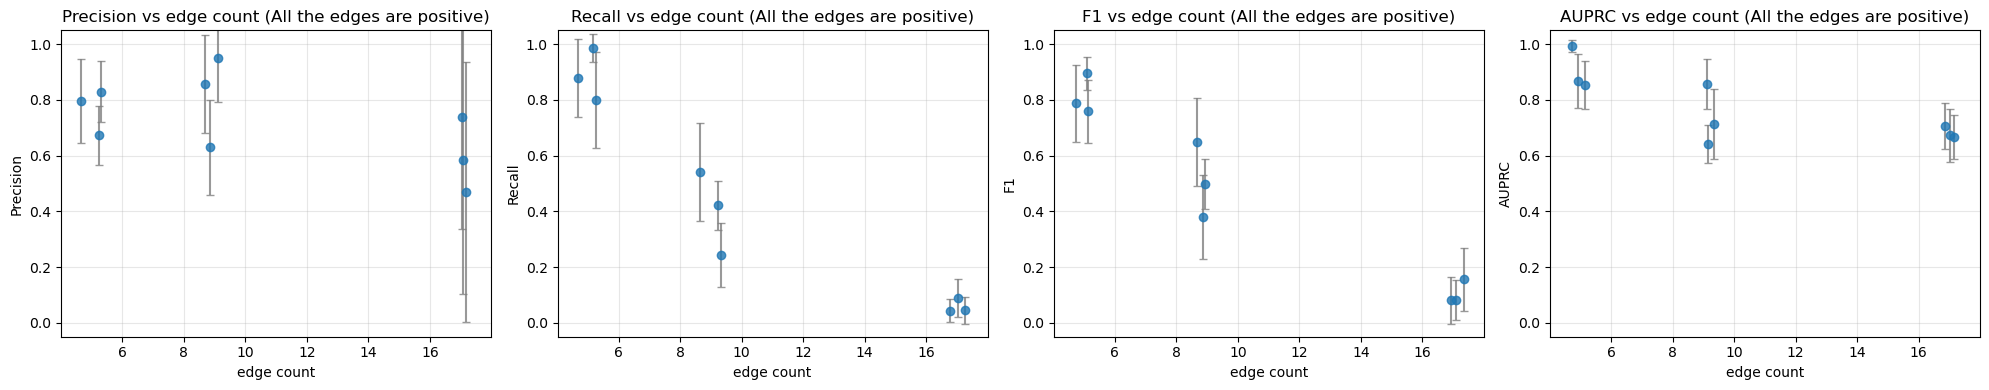

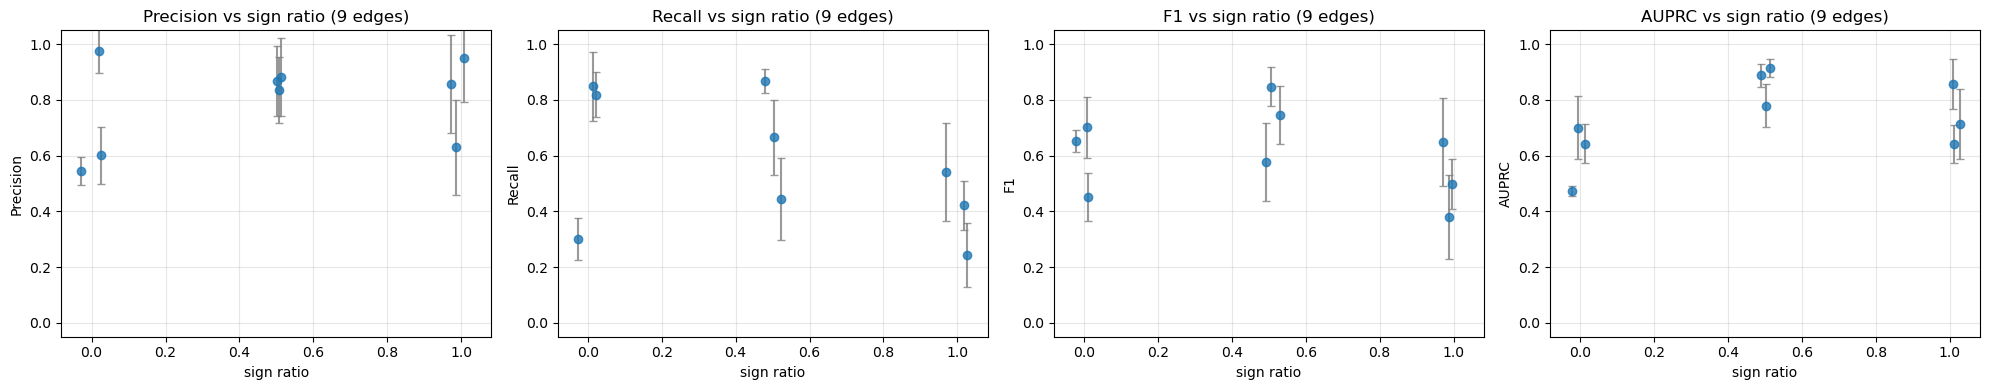

In [12]:
df, summary = prepare_plot_data(results_df)

fig_density = plot_metrics_vs_parameter(summary, x_col="edge_count",
    filter_cell=["center", "density"], title_suffix=" (All the edges are positive)")
plt.show()

fig_sign = plot_metrics_vs_parameter(summary, x_col="sign_ratio",
    filter_cell=["center", "sign_ratio"], title_suffix=" (9 edges)")
plt.show()

In [13]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def reconstruct_matrix(raw, gene_names=None):
    """
    Reconstructs a labeled DataFrame from a matrix stored in the
    {'__type__': 'DataFrame', 'index': ..., 'columns': ..., 'data': ...}
    wrapper format used in these result JSONs. Falls back to gene_names for
    labeling if the wrapper's own index/columns are missing or look wrong.

    Args:
        raw (dict or list): The raw value from results[<matrix_key>].
        gene_names (list of str, optional): Fallback labels if raw doesn't
                                            carry its own index/columns.

    Returns:
        pd.DataFrame: Labeled square matrix.
    """
    if isinstance(raw, dict) and raw.get("__type__") == "DataFrame":
        return pd.DataFrame(raw["data"], index=raw["index"], columns=raw["columns"])
    # fallback: plain nested list/array
    df = pd.DataFrame(raw)
    if gene_names is not None and df.shape == (len(gene_names), len(gene_names)):
        df.index = gene_names
        df.columns = gene_names
    return df


def extract_pairwise_long(matrix_t1, matrix_t2, gene_names, file_label, include_diagonal=False):
    """
    Extracts matched (t1, t2) correlation values for every gene pair from two
    labeled matrices into long-form rows, for building a paired comparison plot.

    Args:
        matrix_t1 (pd.DataFrame): Correlation matrix at t1, labeled by gene_names.
        matrix_t2 (pd.DataFrame): Correlation matrix at t2, same labeling.
        gene_names (list of str): Gene names, used to iterate pairs in order.
        file_label (str): Identifier for the source file (e.g. filename),
                          attached to every row for traceability/coloring.
        include_diagonal (bool): If True, includes gi == gj (self) pairs.

    Returns:
        list of dict: Rows with gene_i, gene_j, t1_value, t2_value, file.
    """
    rows = []
    for gi in gene_names:
        for gj in gene_names:
            if gi == gj and not include_diagonal:
                continue
            if gi not in matrix_t1.index or gj not in matrix_t1.columns:
                continue
            if gi not in matrix_t2.index or gj not in matrix_t2.columns:
                continue
            rows.append({
                "gene_i": gi, "gene_j": gj,
                "t1_value": matrix_t1.loc[gi, gj],
                "t2_value": matrix_t2.loc[gi, gj],
                "file": file_label,
            })
    return rows


def build_paired_t1_t2_df(json_files, matrix_key_t1="twin_pair_correlation_matrix_t1",
                          matrix_key_t2="twin_pair_correlation_matrix_t2", include_diagonal=False):
    """
    Loads a list of result JSON files and builds a long-form DataFrame of
    paired (t1, t2) correlation values for every gene pair, across all files.

    Args:
        json_files (list of str): Paths to result JSON files.
        matrix_key_t1 (str): Key in each results dict holding the t1 matrix.
        matrix_key_t2 (str): Key in each results dict holding the t2 matrix.
        include_diagonal (bool): Passed to extract_pairwise_long.

    Returns:
        pd.DataFrame: Columns gene_i, gene_j, t1_value, t2_value, file.
    """
    all_rows = []
    for jf in json_files:
        with open(jf) as f:
            results = json.load(f)
        gene_names = get_correct_gene_names(results)

        m1 = reconstruct_matrix(results[matrix_key_t1], gene_names)
        m2 = reconstruct_matrix(results[matrix_key_t2], gene_names)

        all_rows.extend(extract_pairwise_long(m1, m2, gene_names,
                                              file_label=jf, include_diagonal=include_diagonal))
    return pd.DataFrame(all_rows)


import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def get_unique_gene_pairs(gene_names):
    """
    Returns unique unordered gene pairs (gi, gj) with gi appearing before gj
    in gene_names, avoiding duplicate (and, for symmetric correlation
    matrices, redundant) mirrored pairs.

    Args:
        gene_names (list of str): Gene names, in the order to use for
                                  determining pair uniqueness.

    Returns:
        list of tuple: Unique (gi, gj) pairs.
    """
    pairs = []
    for i in range(len(gene_names)):
        for j in range(i + 1, len(gene_names)):
            pairs.append((gene_names[i], gene_names[j]))
    return pairs


def plot_paired_dotplot_per_gene_pair(paired_df, gene_names, ncols=5,
                                      subplot_size=(2.5, 3), point_alpha=0.7,
                                      color_by_file=False):
    """
    Creates one subplot per unique gene pair, each showing a paired
    before/after dot plot: two x-positions ('t1', 't2'), one line per file
    connecting that file's t1 value to its t2 value for that gene pair.

    Args:
        paired_df (pd.DataFrame): Output of build_paired_t1_t2_df, with
                                  columns gene_i, gene_j, t1_value, t2_value, file.
        gene_names (list of str): Gene names, used to determine subplot order
                                  and which unique pairs to plot (via
                                  get_unique_gene_pairs).
        ncols (int): Number of subplot columns; rows are computed automatically.
        subplot_size (tuple): (width, height) per subplot in inches.
        point_alpha (float): Point/line transparency.
        color_by_file (bool): If True, colors each file's line distinctly
                              (legend shown only if the number of files is
                              small enough to stay readable). If False, all
                              lines are a single color, distinguishing only
                              the paired structure.

    Returns:
        matplotlib.figure.Figure
    """
    unique_pairs = get_unique_gene_pairs(gene_names)
    n_pairs = len(unique_pairs)
    nrows = math.ceil(n_pairs / ncols)

    fig, axes = plt.subplots(nrows, ncols,
                             figsize=(subplot_size[0] * ncols, subplot_size[1] * nrows),
                             squeeze=False)

    files = paired_df["file"].unique()
    cmap = plt.cm.get_cmap("tab10", max(len(files), 1))
    file_colors = {f: cmap(i % 10) for i, f in enumerate(files)}

    for idx, (gi, gj) in enumerate(unique_pairs):
        ax = axes[idx // ncols][idx % ncols]
        subset = paired_df[(paired_df["gene_i"] == gi) & (paired_df["gene_j"] == gj)]

        for _, row in subset.iterrows():
            color = file_colors[row["file"]] if color_by_file else "steelblue"
            ax.plot([0, 1], [row["t1_value"], row["t2_value"]],
                    marker="o", color=color, alpha=point_alpha, linewidth=1, markersize=5)

        ax.set_xticks([0, 1])
        ax.set_xticklabels(["t1", "t2"])
        ax.set_xlim(-0.3, 1.3)
        ax.axhline(0, color="gray", linewidth=0.5, linestyle=":")
        ax.set_title(f"{gi} - {gj}", fontsize=9)
        ax.grid(alpha=0.2)

    # hide unused subplot axes
    for idx in range(n_pairs, nrows * ncols):
        axes[idx // ncols][idx % ncols].axis("off")

    if color_by_file and len(files) <= 15:
        handles = [plt.Line2D([0], [0], color=file_colors[f], marker="o", linestyle="-")
                  for f in files]
        fig.legend(handles, [str(f) for f in files], loc="upper center",
                  bbox_to_anchor=(0.5, 1.02), ncol=min(len(files), 5), fontsize=7)

    fig.suptitle("Twin-pair correlation: t1 → t2, per gene pair", y=1.05 if color_by_file else 1.0)
    plt.tight_layout()
    return fig